# NB02 — Baseline Anomaly Detection Models
## BAREKENG MS 21575 — A Comparative Analysis of Isolation Forest and Local Outlier Factor

**Stage overview.** Standardises the seven features and fits the three baseline detectors
reported in the manuscript: Isolation Forest at contamination 0.05, and Local Outlier
Factor at both `'auto'` and 0.05. Produces Table 1 and the per-record label matrix that
every downstream notebook consumes.

| | |
|---|---|
| **Manuscript link** | §2.2 Preprocessing (Eq. 1); §2.3 Algorithms (Eqs. 2–4); Table 1; Figures 4–5 |
| **Reviewer comments** | none directly — this is the parity baseline everything else rests on |
| **Upstream** | NB01 → `summary_NB01.json` |
| **Downstream** | NB03, NB04, NB06 |

### Inputs
| Artifact | Path |
|---|---|
| Handshake | `outputs/notebook_exports/summary_NB01.json` |
| Feature matrix | `data/processed/features_raw.parquet` (100,000 × 7) |

### Outputs
| Artifact | Path |
|---|---|
| Label matrix | `data/processed/anomaly_labels.parquet` |
| Table 1 | `outputs/tables/nb02_table1_anomaly_counts.csv` |
| Figure 4 | `outputs/figures/nb02_fig4_if_scatter.png` |
| Figure 5 | `outputs/figures/nb02_fig5_lof_scatter.png` |
| Handshake | `outputs/notebook_exports/summary_NB02.json` |

---

> ### The parity checkpoint
>
> | Model | Expected | Diagnostic value |
> |---|---|---|
> | Isolation Forest, contamination 0.05 | 5,000 | **none** — this is `0.05 × 100,000` and holds for any input whatsoever |
> | LOF, contamination 0.05 | 5,000 | **none** — same reason |
> | **LOF, contamination `'auto'`** | **2,565** | **this is the real check** |
>
> Only the LOF `'auto'` count is data-dependent: the threshold is derived from the fitted
> local-outlier-factor distribution rather than imposed. It is the first number in this
> pipeline that can actually disagree with the manuscript, and the first evidence that the
> feature matrix reached the models intact.
>
> All three counts were reproduced locally before this notebook was written, by porting
> the original notebook's cells [3], [4], [5] and [33]. If 2,565 misses here, suspect the
> environment before the code — see Cell 02.

In [1]:
# Cell 01 — Mount Storage & Define Paths

import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
PROJECT_FOLDER_NAME = "BarekengPaper1-Revision"

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    BASE = Path(f"/content/drive/MyDrive/{PROJECT_FOLDER_NAME}")
else:
    BASE = Path.cwd()
    if BASE.name == "notebooks":
        BASE = BASE.parent

RAW = BASE / "data" / "raw"
INTERIM = BASE / "data" / "interim"
PROCESSED = BASE / "data" / "processed"
FIGURES = BASE / "outputs" / "figures"
TABLES = BASE / "outputs" / "tables"
MODELS = BASE / "outputs" / "models"
EXPORTS = BASE / "outputs" / "notebook_exports"
MANUSCRIPT = BASE / "outputs" / "manuscript_ready"

for d in [RAW, INTERIM, PROCESSED, FIGURES, TABLES, MODELS, EXPORTS, MANUSCRIPT]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Environment : {'Google Colab' if IN_COLAB else 'Local workstation'}")
print(f"Base        : {BASE}")

Mounted at /content/drive
Environment : Google Colab
Base        : /content/drive/MyDrive/BarekengPaper1-Revision


In [2]:
# Cell 02 — Imports, Global Seed, Style & Environment Capture
# scikit-learn and scipy are recorded here because they, not pandas, govern the parity
# anchors. NB01 could not report them -- it imports neither.

import json
import platform
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

ENVIRONMENT = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__,
}

# The environment in which Tables 1-4 were demonstrably reproduced.
PARITY_ENVIRONMENT = {"numpy": "2.0.2", "pandas": "2.3.3", "scikit_learn": "1.6.1", "scipy": "1.13.1"}
ENV_DELTA = {k: (v, ENVIRONMENT[k]) for k, v in PARITY_ENVIRONMENT.items() if ENVIRONMENT[k] != v}

print(f"Seed fixed to {SEED}.\n")
for pkg, ver in ENVIRONMENT.items():
    print(f"  {pkg:<14} {ver}")

if ENV_DELTA:
    print("\nNote: differs from the parity-verified environment:")
    for pkg, (want, got) in ENV_DELTA.items():
        print(f"  {pkg:<14} verified {want}  ->  here {got}")
    print("Not an error. Recorded so a parity miss below can be attributed correctly.")
else:
    print("\nEnvironment matches the parity-verified set exactly.")

Seed fixed to 42.

  python         3.13.15
  numpy          2.1.3
  pandas         2.2.3
  scikit_learn   1.6.1
  scipy          1.16.3
  matplotlib     3.10.0
  seaborn        0.13.2

Note: differs from the parity-verified environment:
  numpy          verified 2.0.2  ->  here 2.1.3
  pandas         verified 2.3.3  ->  here 2.2.3
  scipy          verified 1.13.1  ->  here 1.16.3
Not an error. Recorded so a parity miss below can be attributed correctly.


In [3]:
# Cell 03 — Validate Upstream Handshake (NB01 -> NB02)

UPSTREAM = "NB01"
handshake_path = EXPORTS / f"summary_{UPSTREAM}.json"

if not handshake_path.exists():
    raise FileNotFoundError(
        f"Missing upstream handshake: {handshake_path}\n"
        f"Run {UPSTREAM} (01_data_and_eda.ipynb) before this notebook."
    )

with open(handshake_path, "r", encoding="utf-8") as fh:
    upstream = json.load(fh)

if upstream.get("status") != "SUCCESS":
    raise AssertionError(f"{UPSTREAM} did not report SUCCESS (status={upstream.get('status')!r}).")

upstream_assertions = upstream.get("assertions", {})
failed = [k for k, v in upstream_assertions.items() if not v]
if failed:
    raise AssertionError(f"{UPSTREAM} assertions failed: {failed}. Re-run {UPSTREAM} before continuing.")

# The single most important upstream guarantee: the currency strip left nothing to impute.
if upstream["key_results"]["nan_after_cleaning"] != 0:
    raise AssertionError(
        "Upstream reported a non-zero NaN count after currency stripping. The feature "
        "matrix is not trustworthy -- imputed values would sit in the upper tail and "
        "corrupt both detectors. See REPRODUCIBILITY.md section 4.1."
    )

if not upstream["data_provenance"]["checksum_matches_parity_snapshot"]:
    print(
        "*** WARNING: NB01 read a dataset whose SHA-256 differs from the parity snapshot.\n"
        "    A miss on LOF(auto) = 2,565 below is then expected and attributable to the data."
    )

UPSTREAM_MEDIANS = upstream["key_results"]["median"]
FEATURES = upstream["key_results"]["feature_names"]

print(f"Upstream {UPSTREAM} verified.")
print(f"  ran at            : {upstream['timestamp']}")
print(f"  feature shape     : {upstream['key_results']['feature_shape']}")
print(f"  NaN after cleaning: {upstream['key_results']['nan_after_cleaning']}")
print(f"  checksum match    : {upstream['data_provenance']['checksum_matches_parity_snapshot']}")
print(f"  assertions passed : {len(upstream_assertions)}/{len(upstream_assertions)}")

Upstream NB01 verified.
  ran at            : 2026-09-20T19:47:36.642079
  feature shape     : [100000, 7]
  NaN after cleaning: 0
  checksum match    : True
  assertions passed : 5/5


---
## Section 1 — Preprocessing (Manuscript §2.2, Equation 1)

In [4]:
# Cell 04 — Load: Feature Matrix from NB01

features_path = PROCESSED / "features_raw.parquet"
if not features_path.exists():
    raise FileNotFoundError(f"Missing {features_path}. Re-run NB01.")

df_features = pd.read_parquet(features_path)

assert list(df_features.columns) == FEATURES, (
    f"Column mismatch against the upstream handshake.\n"
    f"  expected: {FEATURES}\n  found:    {list(df_features.columns)}"
)
assert df_features.shape == (100_000, 7), f"Unexpected shape {df_features.shape}"
assert df_features.isna().sum().sum() == 0, "Feature matrix contains NaN; do not proceed."

# Confirm this is the same matrix NB01 described, not a stale or regenerated file.
drift = {
    c: (UPSTREAM_MEDIANS[c], float(df_features[c].median()))
    for c in FEATURES
    if not np.isclose(UPSTREAM_MEDIANS[c], df_features[c].median(), rtol=0, atol=1e-9)
}
if drift:
    raise AssertionError(
        f"Feature medians disagree with the NB01 handshake: {drift}\n"
        "The parquet on disk is not the one NB01 exported."
    )

print(f"Loaded {df_features.shape[0]:,} x {df_features.shape[1]} feature matrix")
print("Medians match the NB01 handshake exactly; no drift between stages.")

Loaded 100,000 x 7 feature matrix
Medians match the NB01 handshake exactly; no drift between stages.


In [5]:
# Cell 05 — Transform: StandardScaler (Manuscript Equation 1)
# Both detectors are fitted on the SCALED matrix. This matters for parity: the original
# notebook's cells [5] and [33] both use X_scaled. Fitting LOF on raw values -- as the
# original's superseded cell [10] did -- does not reproduce the published counts.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

assert X_scaled.shape == (100_000, 7)
assert np.allclose(X_scaled.mean(axis=0), 0, atol=1e-9), "Scaled features are not zero-mean"
assert np.allclose(X_scaled.std(axis=0), 1, atol=1e-9), "Scaled features are not unit-variance"

print(f"Standardised to {X_scaled.shape}")
print(f"  mean  in [{X_scaled.mean(axis=0).min():+.2e}, {X_scaled.mean(axis=0).max():+.2e}]")
print(f"  std   in [{X_scaled.std(axis=0).min():.6f}, {X_scaled.std(axis=0).max():.6f}]")

Standardised to (100000, 7)
  mean  in [-2.44e-17, +5.71e-17]
  std   in [1.000000, 1.000000]


---
## Section 2 — Baseline Detectors (Manuscript §2.3, Equations 2–4)

In [6]:
# Cell 06 — Model: Isolation Forest (contamination = 0.05)
# Ported from the original notebook's cell [5].

iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=SEED)
iso.fit(X_scaled)

if_labels = iso.predict(X_scaled)          # -1 anomaly, +1 normal
if_scores = iso.decision_function(X_scaled)  # lower = more anomalous

IF_COUNT = int((if_labels == -1).sum())
EXPECTED_IF = 5_000

assert IF_COUNT == EXPECTED_IF, (
    f"Isolation Forest flagged {IF_COUNT:,}, expected {EXPECTED_IF:,}. "
    "This count is contamination x n and should be exact by construction; a miss means "
    "the input row count is wrong, not the model."
)

print(f"Isolation Forest : {IF_COUNT:,} anomalies ({IF_COUNT / len(if_labels):.2%})")
print(f"  n_estimators=100, contamination=0.05, random_state={SEED}, fitted on X_scaled")
print(f"  decision_function range: [{if_scores.min():.4f}, {if_scores.max():.4f}]")
print("\n  Note: 5,000 is 0.05 x 100,000 and would hold on corrupted input too.")
print("  The real check is LOF(auto) in the next cell.")

Isolation Forest : 5,000 anomalies (5.00%)
  n_estimators=100, contamination=0.05, random_state=42, fitted on X_scaled
  decision_function range: [-0.2958, 0.2121]

  Note: 5,000 is 0.05 x 100,000 and would hold on corrupted input too.
  The real check is LOF(auto) in the next cell.


In [7]:
# Cell 07 — Model: Local Outlier Factor, 'auto' and 0.05 (THE PARITY CHECKPOINT)
# Ported from the original notebook's cell [33] -- the canonical LOF configuration.
# Cells [10] and [31] of that notebook use different features/scaling and are superseded.

lof_auto = LocalOutlierFactor(n_neighbors=20, contamination="auto")
lof_auto_labels = lof_auto.fit_predict(X_scaled)
lof_auto_scores = -lof_auto.negative_outlier_factor_   # higher = more abnormal

lof_05 = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_05_labels = lof_05.fit_predict(X_scaled)
lof_05_scores = -lof_05.negative_outlier_factor_

LOF_AUTO_COUNT = int((lof_auto_labels == -1).sum())
LOF_05_COUNT = int((lof_05_labels == -1).sum())
EXPECTED_LOF_AUTO = 2_565
EXPECTED_LOF_05 = 5_000

print(f"LOF (auto)  : {LOF_AUTO_COUNT:,} anomalies ({LOF_AUTO_COUNT / 100_000:.2%})   expected {EXPECTED_LOF_AUTO:,}")
print(f"LOF (0.05)  : {LOF_05_COUNT:,} anomalies ({LOF_05_COUNT / 100_000:.2%})   expected {EXPECTED_LOF_05:,}")

assert LOF_05_COUNT == EXPECTED_LOF_05, (
    f"LOF(0.05) flagged {LOF_05_COUNT:,}, expected {EXPECTED_LOF_05:,} (contamination x n)."
)

if LOF_AUTO_COUNT != EXPECTED_LOF_AUTO:
    delta = LOF_AUTO_COUNT - EXPECTED_LOF_AUTO
    env_note = (
        "\n  Environment differs from the parity-verified set:\n"
        + "\n".join(f"    {k}: verified {w} -> here {g}" for k, (w, g) in ENV_DELTA.items())
        if ENV_DELTA else
        "\n  Environment matches the parity-verified set, so version drift is NOT the cause."
    )
    raise AssertionError(
        f"PARITY MISS on the first diagnostic anchor.\n"
        f"  LOF(auto) = {LOF_AUTO_COUNT:,}, manuscript Table 1 reports {EXPECTED_LOF_AUTO:,} "
        f"(delta {delta:+,})\n"
        f"{env_note}\n\n"
        "  Unlike the two 5,000s, this threshold is derived from the fitted LOF score\n"
        "  distribution, so it responds to any change in the input matrix or in\n"
        "  scikit-learn's LOF implementation. Check, in order:\n"
        "    1. scikit-learn version against REPRODUCIBILITY.md section 2\n"
        "    2. that NB01 reported nan_after_cleaning = 0 and a matching SHA-256\n"
        "    3. that both detectors were fitted on X_scaled, all 7 features\n"
        "  Do NOT adjust parameters to force the number to match."
    )

print(f"\nPARITY HELD: LOF(auto) = {LOF_AUTO_COUNT:,} matches manuscript Table 1.")
print("The feature matrix reached the detectors intact.")

LOF (auto)  : 2,565 anomalies (2.56%)   expected 2,565
LOF (0.05)  : 5,000 anomalies (5.00%)   expected 5,000

PARITY HELD: LOF(auto) = 2,565 matches manuscript Table 1.
The feature matrix reached the detectors intact.


In [8]:
# Cell 08 — Transform: Canonical Label Matrix

df_labels = pd.DataFrame({
    "IF_Label": if_labels,
    "IF_Score": if_scores,
    "LOF_Auto_Label": lof_auto_labels,
    "LOF_Auto_Score": lof_auto_scores,
    "LOF_05_Label": lof_05_labels,
    "LOF_05_Score": lof_05_scores,
})

LABEL_COLS = ["IF_Label", "LOF_Auto_Label", "LOF_05_Label"]
for col in LABEL_COLS:
    assert set(df_labels[col].unique()) <= {-1, 1}, f"{col} is not encoded as -1/+1"

assert len(df_labels) == len(df_features), "Label matrix length differs from feature matrix"

# Row order is the only join key between this matrix and features_raw.parquet -- both are
# written without an index. Nothing downstream may sort or reindex either file.
print(f"Label matrix: {df_labels.shape}")
print(f"  encoding: -1 anomaly, +1 normal (scikit-learn native)")
print(f"  IF_Score: decision_function, LOWER = more anomalous")
print(f"  LOF_*_Score: negated negative_outlier_factor_, HIGHER = more abnormal\n")
print(df_labels[LABEL_COLS].apply(lambda s: s.value_counts()).T.rename(
    columns={-1: "anomaly", 1: "normal"}).to_string())

Label matrix: (100000, 6)
  encoding: -1 anomaly, +1 normal (scikit-learn native)
  IF_Score: decision_function, LOWER = more anomalous
  LOF_*_Score: negated negative_outlier_factor_, HIGHER = more abnormal

                normal  anomaly
IF_Label         95000     5000
LOF_Auto_Label   97435     2565
LOF_05_Label     95000     5000


In [9]:
# Cell 09 — Export: Table 1, Anomaly Counts by Model (Manuscript Table 1)

table1 = pd.DataFrame([
    {"Model": "IF (contamination = 0.05)", "Anomaly Count": IF_COUNT},
    {"Model": "LOF (auto)", "Anomaly Count": LOF_AUTO_COUNT},
    {"Model": "LOF (contamination = 0.05)", "Anomaly Count": LOF_05_COUNT},
])
table1["Anomaly %"] = (table1["Anomaly Count"] / 100_000 * 100).map(lambda v: f"{v:.2f}%")
table1["Normal Count"] = 100_000 - table1["Anomaly Count"]

published = {"IF (contamination = 0.05)": 5000, "LOF (auto)": 2565, "LOF (contamination = 0.05)": 5000}
table1["Published"] = table1["Model"].map(published)
table1["Parity"] = np.where(table1["Anomaly Count"] == table1["Published"], "match", "MISS")

assert (table1["Parity"] == "match").all(), f"Table 1 parity failure:\n{table1}"

table1_path = TABLES / "nb02_table1_anomaly_counts.csv"
table1.to_csv(table1_path, index=False)

print(table1.to_string(index=False))
print(f"\nSaved -> {table1_path.name}")

                     Model  Anomaly Count Anomaly %  Normal Count  Published Parity
 IF (contamination = 0.05)           5000     5.00%         95000       5000  match
                LOF (auto)           2565     2.56%         97435       2565  match
LOF (contamination = 0.05)           5000     5.00%         95000       5000  match

Saved -> nb02_table1_anomaly_counts.csv


---
## Section 3 — Publication Figures

Figures 4 and 5 keep the axes used in the submitted manuscript — `Average Medicare Payment
Amount` against `Number of Services` — so the revised figures remain directly comparable to
the published ones. Both axes are log-scaled (skewness 54 and 32 respectively), and normal
points are drawn first at low opacity so the flagged minority stays visible.

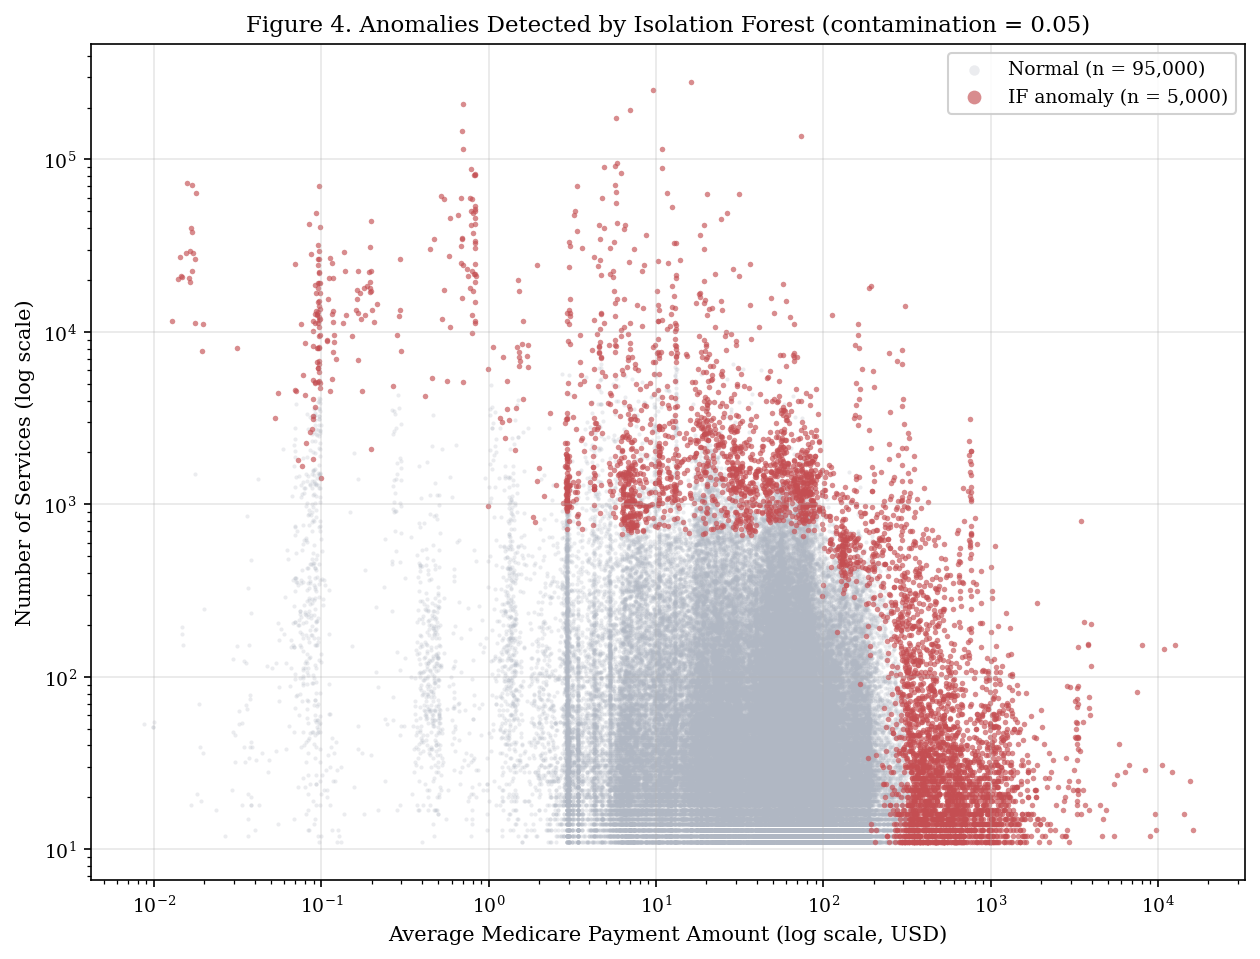

Saved Figure 4 -> nb02_fig4_if_scatter.png (300 dpi)


In [10]:
# Cell 10 — Plot: Figure 4, Isolation Forest Anomalies

X_AXIS = "Average Medicare Payment Amount"
Y_AXIS = "Number of Services"


def scatter_anomalies(labels, title, outfile, flag_colour, flag_label):
    # Normal points first at low alpha; flagged points on top so they are not buried.
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    normal = labels == 1
    anomaly = labels == -1

    ax.scatter(df_features.loc[normal, X_AXIS], df_features.loc[normal, Y_AXIS],
               s=4, c="#B0B7C3", alpha=0.25, linewidths=0, label=f"Normal (n = {normal.sum():,})")
    ax.scatter(df_features.loc[anomaly, X_AXIS], df_features.loc[anomaly, Y_AXIS],
               s=7, c=flag_colour, alpha=0.65, linewidths=0, label=f"{flag_label} (n = {anomaly.sum():,})")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(f"{X_AXIS} (log scale, USD)")
    ax.set_ylabel(f"{Y_AXIS} (log scale)")
    ax.set_title(title)
    ax.legend(loc="upper right", frameon=True, framealpha=0.9, markerscale=2.5)
    fig.tight_layout()
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


fig4_path = FIGURES / "nb02_fig4_if_scatter.png"
scatter_anomalies(
    if_labels,
    "Figure 4. Anomalies Detected by Isolation Forest (contamination = 0.05)",
    fig4_path, "#C44E52", "IF anomaly",
)
print(f"Saved Figure 4 -> {fig4_path.name} (300 dpi)")

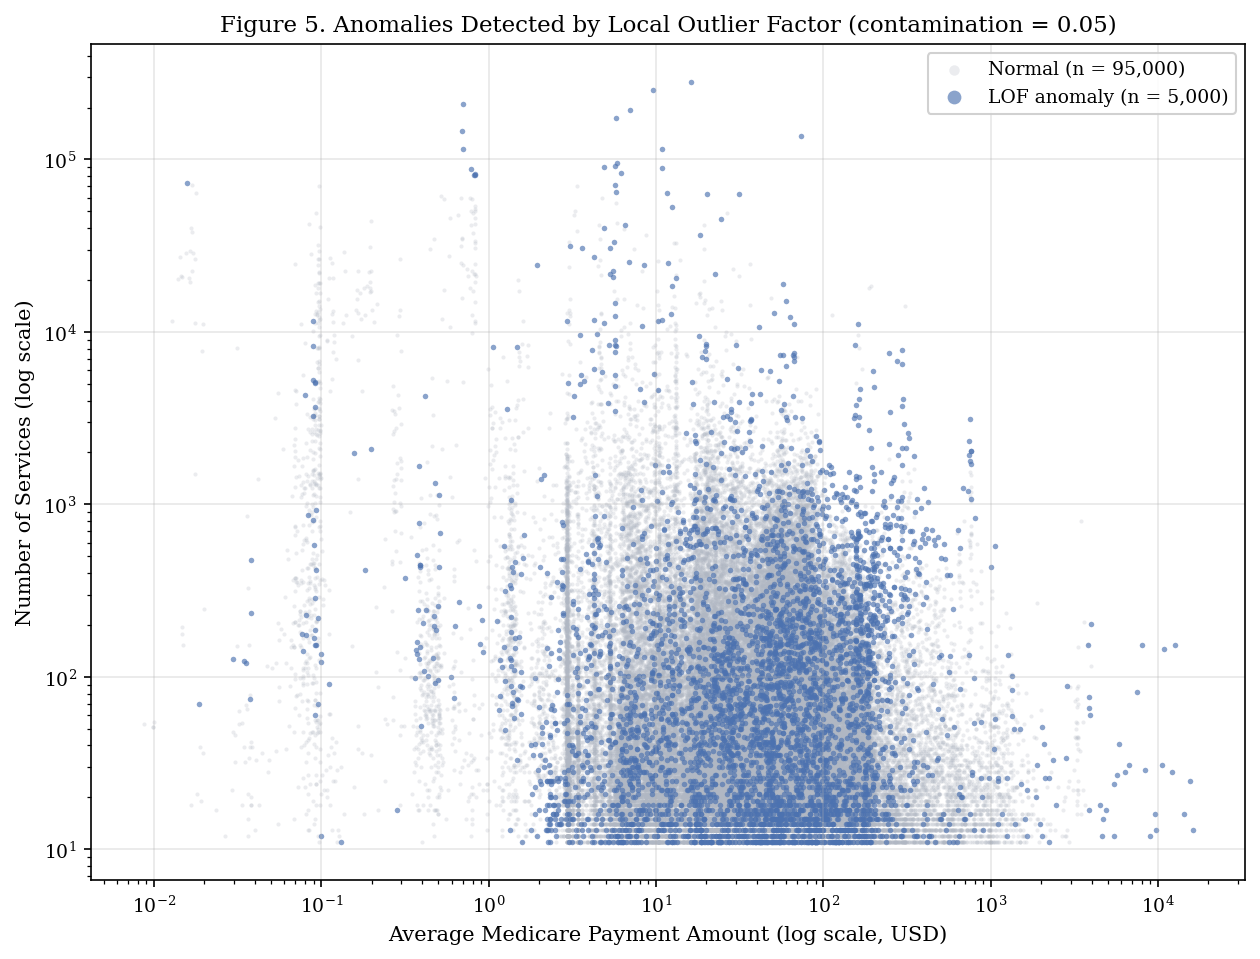

Saved Figure 5 -> nb02_fig5_lof_scatter.png (300 dpi)

Figures 4 and 5 use identical axes and identical anomaly budgets (5,000 each),
so the visible difference in where each model places its flags is the qualitative
counterpart to the low Jaccard overlap quantified in NB04.


In [11]:
# Cell 11 — Plot: Figure 5, Local Outlier Factor Anomalies

fig5_path = FIGURES / "nb02_fig5_lof_scatter.png"
scatter_anomalies(
    lof_05_labels,
    "Figure 5. Anomalies Detected by Local Outlier Factor (contamination = 0.05)",
    fig5_path, "#4C72B0", "LOF anomaly",
)
print(f"Saved Figure 5 -> {fig5_path.name} (300 dpi)")
print(
    "\nFigures 4 and 5 use identical axes and identical anomaly budgets (5,000 each),\n"
    "so the visible difference in where each model places its flags is the qualitative\n"
    "counterpart to the low Jaccard overlap quantified in NB04."
)

---
## Section 4 — Persistence & Handover

In [12]:
# Cell 12 — Export: Label Matrix & JSON Handshake (NB02 -> NB03/NB04/NB06)

labels_path = PROCESSED / "anomaly_labels.parquet"
df_labels.to_parquet(labels_path, index=False)

roundtrip = pd.read_parquet(labels_path)
assert roundtrip.shape == df_labels.shape, "Parquet round-trip changed shape"
assert (roundtrip[LABEL_COLS] == df_labels[LABEL_COLS]).all().all(), "Parquet round-trip altered labels"

summary = {
    "notebook": "NB02",
    "status": "SUCCESS",
    "timestamp": pd.Timestamp.now().isoformat(),
    "environment": ENVIRONMENT,
    "environment_delta_vs_parity_verified": {k: {"verified": w, "observed": g} for k, (w, g) in ENV_DELTA.items()},
    "seed": SEED,
    "inputs_consumed": [
        "outputs/notebook_exports/summary_NB01.json",
        "data/processed/features_raw.parquet",
    ],
    "outputs": {
        "anomaly_labels": "data/processed/anomaly_labels.parquet",
        "table1": "outputs/tables/nb02_table1_anomaly_counts.csv",
        "figure_4": "outputs/figures/nb02_fig4_if_scatter.png",
        "figure_5": "outputs/figures/nb02_fig5_lof_scatter.png",
    },
    "model_parameters": {
        "isolation_forest": {"n_estimators": 100, "contamination": 0.05, "random_state": SEED, "input": "X_scaled"},
        "lof_auto": {"n_neighbors": 20, "contamination": "auto", "input": "X_scaled"},
        "lof_005": {"n_neighbors": 20, "contamination": 0.05, "input": "X_scaled"},
        "scaler": "StandardScaler on all 7 features",
    },
    "key_results": {
        "if_anomaly_count": IF_COUNT,
        "lof_auto_anomaly_count": LOF_AUTO_COUNT,
        "lof_05_anomaly_count": LOF_05_COUNT,
        "if_score_min": float(if_scores.min()),
        "if_score_max": float(if_scores.max()),
        "lof_auto_score_threshold": float(lof_auto_scores[lof_auto_labels == -1].min()),
        "lof_05_score_threshold": float(lof_05_scores[lof_05_labels == -1].min()),
        "label_columns": list(df_labels.columns),
    },
    "parity": {
        "if_count_5000": IF_COUNT == 5000,
        "lof_05_count_5000": LOF_05_COUNT == 5000,
        "lof_auto_count_2565": LOF_AUTO_COUNT == 2565,
        "note": (
            "if_count_5000 and lof_05_count_5000 are contamination x n and carry no "
            "diagnostic value. lof_auto_count_2565 is the data-dependent anchor."
        ),
    },
    "assertions": {
        "upstream_nb01_verified": True,
        "feature_medians_match_upstream": True,
        "scaled_zero_mean_unit_variance": True,
        "labels_encoded_neg1_pos1": True,
        "lof_auto_parity_2565": LOF_AUTO_COUNT == 2565,
        "table1_parity": True,
        "parquet_roundtrip_verified": True,
    },
    "downstream_note": (
        "anomaly_labels.parquet aligns with features_raw.parquet BY ROW ORDER; neither "
        "file carries an index, so nothing downstream may sort or reindex. "
        "NB04 computes Table 2 overlaps -- expect IF n LOF(auto)=341, IF n LOF(0.05)=545, "
        "LOF(auto) n LOF(0.05)=2565, and LOF(auto) must be a strict subset of LOF(0.05). "
        "NB06 requires the recovered group definitions: 'Anomaly' means IF UNION LOF(0.05) "
        "(n=9,455), NOT IF alone -- see REPRODUCIBILITY.md section 5.2."
    ),
}

summary_path = EXPORTS / "summary_NB02.json"
with open(summary_path, "w", encoding="utf-8") as fh:
    json.dump(summary, fh, indent=2)

failed = [k for k, v in summary["assertions"].items() if not v]
if failed:
    raise AssertionError(f"Handshake written but assertions failed: {failed}")

print(f"{labels_path.relative_to(BASE)}  {df_labels.shape}")
print(f"{summary_path.relative_to(BASE)}")
print(f"\nAll {len(summary['assertions'])} assertions passed.")
print(json.dumps(summary["parity"], indent=2))

data/processed/anomaly_labels.parquet  (100000, 6)
outputs/notebook_exports/summary_NB02.json

All 7 assertions passed.
{
  "if_count_5000": true,
  "lof_05_count_5000": true,
  "lof_auto_count_2565": true,
  "note": "if_count_5000 and lof_05_count_5000 are contamination x n and carry no diagnostic value. lof_auto_count_2565 is the data-dependent anchor."
}


---
## NB02 Complete

| Model | Count | Published | |
|---|---|---|---|
| Isolation Forest (0.05) | 5,000 | 5,000 | trivial |
| LOF (0.05) | 5,000 | 5,000 | trivial |
| **LOF (auto)** | **2,565** | **2,565** | **diagnostic — parity held** |

The baseline reproduces the manuscript. Everything downstream now rests on a verified
foundation rather than an assumed one.

**Next:** return `summary_NB02.json`, `nb02_fig4_if_scatter.png`, `nb02_fig5_lof_scatter.png`
and `nb02_table1_anomaly_counts.csv` to the repository, then generate **NB03**
(`03_parameter_sensitivity.ipynb`, editor comment C2).

NB03 needs a decision first: the sweep ranges for `contamination`, `n_estimators` and
`n_neighbors`, **and a citable justification for them**. C2 asks why the parameters were
chosen, not merely whether the results move when they change — a grid with no stated
rationale answers half the comment.